# AP 155 Lab Exercise
---
## Exercise 5: Derivatives (Second derivative with points on a grid)

_Instructions_: 
- **Report figure:**
    - Figure 1: First 5 eigenfunctions of a quantum harmonic oscillator.
    - Figure 2: Corresponding local kinetic energies (both approximation and analytical)
- **Report discussion:**
    - What is the significance of finite difference methods in numerical modeling?
    - For the central-difference calculation of local kinetic energy, how accurate is the numerical second derivative compared to the exact solution, what is the optimal step size, and how are edge points handled?
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Baculo, Ezira Lojelle
- _Student No._: 2024-11845
- _Section_: THR-TX-3

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

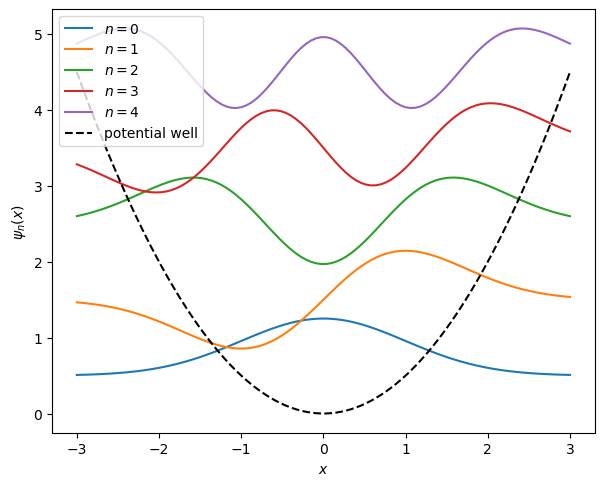

In [173]:
fig1

#### Figure 1. First five normalized eigenfunctions of a quantum harmonic oscillator.

Figure 1 shows the first five normalized eigenfunctions, $(\psi_n(x))$, for quantum states $(n=0,1,2,3,4)$. In order to view the energy levels and their corresponding wavefunctions on the same graph, each wavefunction is vertically shifted by its corresponding energy eigenvalue $(E_n)$. The figure shows how the number of nodes increases and how the shape changes as the quantum number rises.

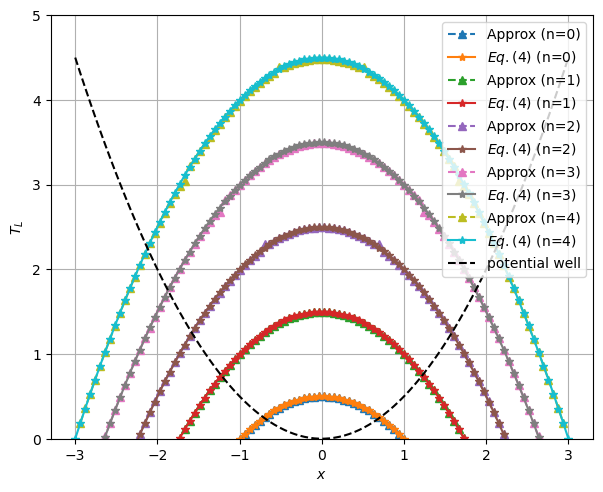

In [172]:
fig2

#### Figure 2. Corresponding local kinetic energies (both approximation and analytical).

For the first five quantum states, Figure 2 emphasizes the exact analytical solution with the local kinetic energy $(T_L)$ computed using the central-difference approximation. The accuracy of the numerical approach is shown by the close overlap between the analytical and approximate curves. For reference, the harmonic oscillator potential well is also displayed.

### Report discussion

(1) In numerical modeling, finite difference methods are crucial because they offer a useful means of approximating derivatives in situations where exact analytical solutions are hard to find or impractical. Continuous differential equations can be transformed into forms that computers can evaluate effectively by substituting algebraic expressions based on nearby grid points for derivatives. The local kinetic energy in this quantum harmonic oscillator problem can be computed numerically thanks to the central-difference method's approximation of the wavefunction's second derivative. Because the grid spacing can be changed to balance accuracy, computational cost, and numerical stability, finite difference methods are also adaptable. For issues relating to heat transfer, fluid flow, wave propagation, and quantum mechanics, they are frequently utilized in physics, engineering, and applied mathematics. Overall, finite difference methods are a vital tool in scientific computing and numerical simulation because they offer a crucial link between continuous mathematical models and discrete computational computations.
\
\
(2) For the first five quantum states, the local kinetic-energy values obtained from the central-difference approximation closely matched the analytical solution. The grid-size search yielded a minimum mean absolute error of about $(3.11\times10^{-8})$ at $(N=49{,}238)$ grid points. This means that the ideal step size is roughly $(h=1.22\times10^{-4})$. When a sufficiently fine grid is used, the numerical second derivative is highly accurate for this problem, as shown by the very small error and close overlap of the numerical and analytical curves. Reducing $(h)$ typically lowers truncation error because the central-difference formula is second-order accurate. However, floating-point round-off effects can be worsened by extremely small step sizes. Because the central-difference formula requires neighboring points on both sides, the first and last grid points are not included in the numerical computation. Therefore, only interior points are used for the numerical second derivative.

### Other comments

- Note to self: panoorin ulit ang lec vids kasi hindi ko na-gets slight.
- Hindi ko po talaga alam kung paano gawin yung Part (E).
- Medyo nalito po kasi hindi ko pa po na-take ang 141 hehehe. Ang na-gets ko lang pong gawin is yung pag-plot, pero yung iba po ay hindi na hehehe. 
- I asked another Physics major friend to check for possible inaccuracies. 

#### Disclosure of AI Use:

I acknowledge the use of Gemini (accessed September 2026) to generate the first draft of the algorithms of the exercise, especially in Part (e). All AI-assisted suggestions were reviewed and revised with the use of the proper references to ensure accuracy and clarity.

### References

7.5 The Quantum Harmonic Oscillator - University physics volume 3 | OpenStax. (n.d.). Openstax.Org. Retrieved September 22, 2026, from https://openstax.org/books/university-physics-volume-3/pages/7-5-the-quantum-harmonic-oscillator ([OpenStax][1])

1.1. Approximating derivatives — MUDE textbook. (2026, September 3). Tudelft.Nl. https://mude.citg.tudelft.nl/book/2026-draft/numerical_methods/0-approximating-derivatives.html ([Mude][2])

1.2. Diffusion equation — MUDE textbook. (2025, November 5). Tudelft.Nl. https://mude.citg.tudelft.nl/book/2025/numerical_methods_for_PDEs/diffusion_equation.html ([Mude][3])


[1]: https://openstax.org/books/university-physics-volume-3/pages/7-5-the-quantum-harmonic-oscillator?utm_source=chatgpt.com "7.5 The Quantum Harmonic Oscillator - University Physics Volume 3 | OpenStax"
[2]: https://mude.citg.tudelft.nl/book/2026-draft/numerical_methods/0-approximating-derivatives.html?utm_source=chatgpt.com "1.1. Approximating derivatives — MUDE textbook"
[3]: https://mude.citg.tudelft.nl/book/2025/numerical_methods_for_PDEs/diffusion_equation.html?utm_source=chatgpt.com "1.2. Diffusion Equation — MUDE textbook"


---
## Section 2: Code

In [171]:
import numpy as np
import matplotlib.pyplot as plt

### Problem: Local kinetic energy in quantum mechanics

An important problem in one-dimensional single-particle quantum mechanics is the har-
monic oscillator; for this case, the time-independent Schr¨odinger equation takes the form:
$$ -\frac{\hbar^2}{2m} \frac{d^2 \psi(x)}{dx^2} + \frac{1}{2} m\omega^2 x^2  \psi(x) = E\psi(x) \tag{1} $$

where $\hbar$ is Planck’s constant (divided by $2\pi$) and the particle’s mass is $m$. The left-hand side
is made up of the kinetic energy (involving a second derivative) and the potential energy
(involving a term quadratic in $x$). The $\omega$ is the (classical) angular frequency.


Every quantum mechanics textbook discusses how to solve this problem. As you (may) have (already) learned in Physics 141, the energy eigenvalues and the normalized eigenfunctions are given by:
$$ E_n = \left(n + \frac{1}{2} \right) \hbar\omega \tag{2}$$

$$ \psi_n (x) = \frac{1}{\sqrt{2^n n!}} \left( \frac{m\omega}{\pi \hbar}\right)^{1/4} H_n \left(\sqrt{\frac{m\omega}{\hbar}} x\right) e^{-m\omega x^2/(2\hbar)} \tag{3}$$

where $n$ is a discrete index (a nonnegative integer) and $H_n(x)$ is the Hermite polynomial.

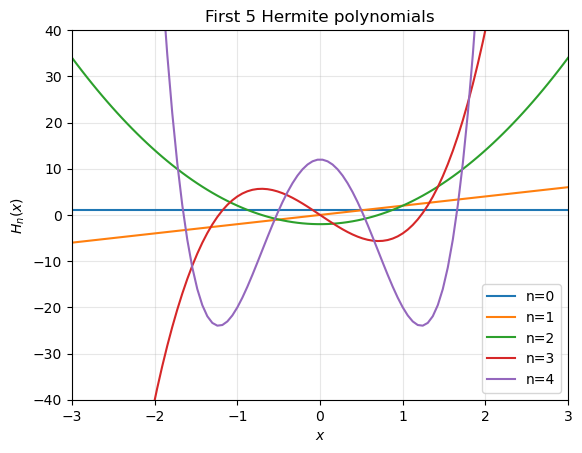

In [170]:
# the Hermite polynomial can be generated using a recurrence relation
# starting from the first two Hermite polynomials we can obtain any other Hermite polynomial with index n

import numpy as np
from scipy.special import factorial

def hermite(n, x):
    if n == 0:
        return np.ones_like(x, dtype=float), np.zeros_like(x, dtype=float)
    if n == 1:
        return 2.0 * x, 2.0 * np.ones_like(x, dtype=float)

    # for n>= 2
    val0 = np.ones_like(x, dtype=float)
    val1 = 2.0 * x
    for j in range(1, n):
        val2 = 2 * x * val1 - 2 * j * val0
        val0, val1 = val1, val2

    dval2 = 2 * n * val0
    return val2, dval2

xlist = np.linspace(-3,3,100)

fig, ax = plt.subplots()

for n in range(0, 5, 1):
    Hnlist, dHnlist = hermite(n, x=xlist)
    ax.plot(xlist, Hnlist, label=fr'n={n}')

ax.legend()
ax.set(xlabel=r'$x$', ylabel=r'$H_n(x)$', ylim=(-40,40), xlim=(-3,3), title='First 5 Hermite polynomials')
ax.grid(True, alpha=0.3)
plt.show()

(a) Create two functions, one that evaluates Eq. $(2)$ and another that evaluates Eq. $(3)$. Use the function above `hermite(n, x)` to evaluate the Hermite polynomial term in the eigenfunction equation. Set all the physical constants to $1$ for simplicity ($m=\hbar=\omega=1$).

In [169]:
def psiQHO(n, x, m=1, omega=1, hbar=1):
    """ 
    This evaluates the normalized eigenfunction of a 1D quantum harmonic oscillator
    at position x for quantum number n.
    """
    # Hermite Polynomial
    Hn, _ = hermite(n,x) 

    # Calculate normalization factor
    normalization = 1.0 / np.sqrt((2.0**n) * factorial(n)) * ((m*omega) / (np.pi*hbar))**0.25
    
    # Calculate Gaussian exponent
    gaussian = np.exp(-m * omega * (x**2) / (2.0*hbar))

    # Normalized eigenfunction
    return normalization * Hn * gaussian

def energyQHO(n, hbar=1, omega=1):
    """ 
    This evaluates the energy eigenvalue of a 1D quantum harmonic oscillator 
    for quantum number n.
    """
    return (n + 0.5) * hbar * omega

(b) **[FIGURE 1]** 
- Use your eigenfunction function to generate data for the first five quantum states ($n = 0, 1, 2, 3, 4$) using a 100-point spatial grid of $x_i$ from $x = -3$ to $x = 3$.
- Plot all five curves on a single set of axes.
- Shift each wavefunction vertically by adding its energy eigenvalue $E_n$ to the calculated $\psi(x_i)$ values.

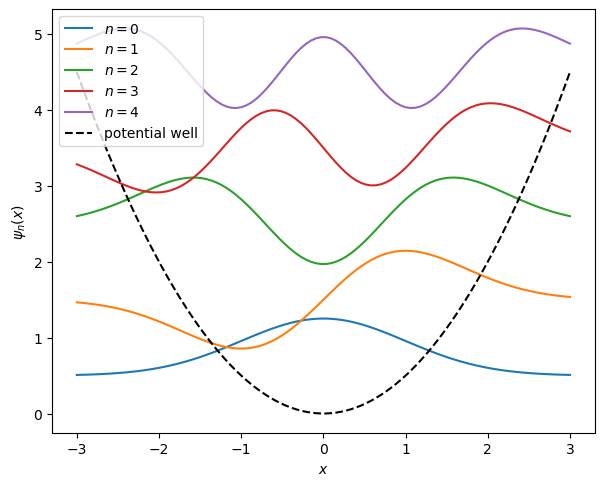

In [168]:
# Note: Make a grid of $\psi_n (x_i)$

# 100-point spatial grid from -3 to 3
x = np.linspace(-3, 3, 100)

# Generate psi_n(x_i) for n = 0, 1, 2, 3, 4
psi = np.array([psiQHO(n, x) for n in range(5)])

# Plot all five wavefunctions shifted by their energies
fig1, ax = plt.subplots(figsize=(7, 5.5))

for n, psi_n in enumerate(psi):
    E_n = energyQHO(n)
    ax.plot(x, psi_n + E_n, label=f"$n={n}$")

# Add the harmonic oscillator potential well: V(x) = 1/2 x^2
potential = 0.5 * x**2
ax.plot(x, potential, "k--", label="potential well")

# Plot diagram
ax.set_xlabel("$x$")
ax.set_ylabel("$\\psi_n(x)$")
ax.grid(False)
ax.legend()

plt.show()

(c) Next, compute the particle's local kinetic energy $T_L$ using two different methods. First, write a function to calculate the exact analytical values across the domain $x \in [-3, 3]$ using the formula:
$$ T_L = \left( n + \frac{1}{2} \right)\hbar\omega - \frac{1}{2} m\omega^2 x^2.  \tag{4}$$
These results will serve as your analytical benchmark.

In [167]:
# Note: Use T_L = E_n - V

def analytical(n, x, hbar=1, omega=1, m=1):
    """ 
    Calculate exact local kinetic energy T_L(x).
    """
    # Energy eigenvalue
    energy = energyQHO(n, hbar=hbar, omega=omega)

    # Harmonic oscillator potential
    potential = 0.5 * m * omega**2 * x**2

    # T_L = E_n - V(x)
    return energy - potential

(d) **[FIGURE 2]** 
- Next, compute the local kinetic energy numerically using the operator definition:
$$T_L= \frac{\hat{T}\psi(x)}{\psi(x)} = \frac{1}{\psi(x)}\left[-\frac{\hbar^2}{2m}\frac{d\psi^2(x)}{dx}\right]. \tag{5}$$

- Write a function that evaluates the rightmost-hand side of Eq. (5) using the central-difference approximation on the spatial grid from part (b).

*Recall the central-difference formula:$$\frac{d^2 \psi(x)}{dx^2} \rightarrow  f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)$$*

- Generate a plot that compares the analytical values of $T_L$ and the approximated values for $T_L$ for the first 5 levels.

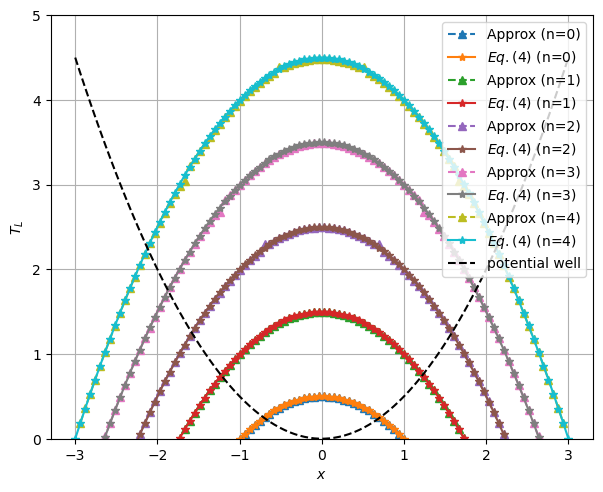

In [166]:
# Note: Using the $\psi$ part of the grid from Part A, employ central difference approx. to $\psi'' (x)$. 

def kinetic_fd(n, x, m=1, hbar=1):
    """
    Calculate local kinetic energy using a central difference.
    """
    # Evaluate the wavefunction on the spatial grid
    psi = psiQHO(n, x, m=m, omega=1, hbar=hbar)

    # Uniform grid spacing
    h = x[1] - x[0]

    # Central-difference approximation of the second derivative
    d2psi = (psi[2:] - 2 * psi[1:-1] + psi[:-2]) / h**2

    # Apply the kinetic-energy operator
    return -(hbar**2 / (2 * m)) * d2psi / psi[1:-1]

x = np.linspace(-3, 3, 100)

fig2, ax = plt.subplots(figsize=(7, 5.5))

for n in range(5):
    # Exact analytical local kinetic energy
    T_exact = analytical(n, x)

    # Numerical result is defined only at interior points
    T_num = kinetic_fd(n, x)

    # Corresponding interior x-values
    x_inner = x[1:-1]

    # Plot analytical and numerical results
    ax.plot(x_inner, T_num, "^--", linewidth=1.5, label=f"Approx (n={n})")
    ax.plot(x, T_exact, "*-", linewidth=1.5, label=f"$Eq. (4)$ (n={n})")

# Add the harmonic oscillator potential well: V(x) = 1/2 x^2
potential = 0.5 * x**2
ax.plot(x, potential, "k--", label="potential well")

ax.set_xlabel("$x$")
ax.set_ylabel("$T_L$")
ax.set_ylim(bottom=0, top=5)
ax.grid(True)
ax.legend()

plt.show()

(e) Fixing the domain $x\in[-3,3]$, determine the optimal step size $h$ (or number of grid points $N$) that minimizes the error of the central-difference approximation for the second derivative. You may use the Mean Absolute Error (MAE) function from previous exercises to evaluate the accuracy.

n=0: Optimal h = 1.145048e-04, Minimum MAE = 9.404428e-09
n=1: Optimal h = 1.145048e-04, Minimum MAE = 9.903675e-09
n=2: Optimal h = 1.145048e-04, Minimum MAE = 1.388124e-08
n=3: Optimal h = 1.145048e-04, Minimum MAE = 2.438813e-08
n=4: Optimal h = 1.145048e-04, Minimum MAE = 3.887627e-08


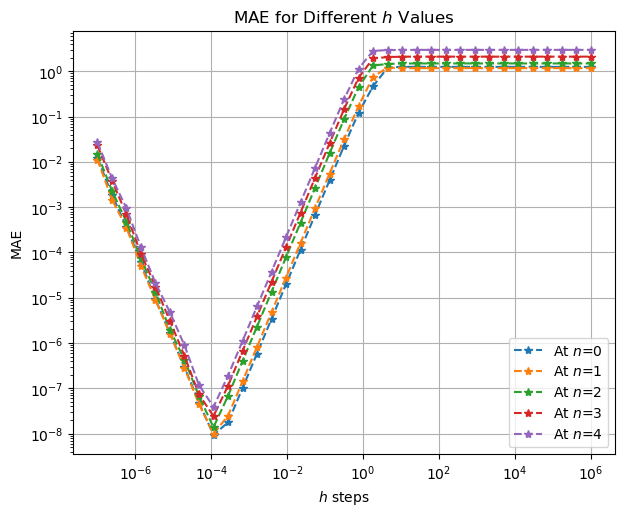

In [165]:
x = np.linspace(-3, 3, 100)

# Step sizes to test
h_values = np.logspace(-7, 6, 35)

# Store MAE for each eigenfunction
errors = {n: [] for n in range(5)}

for h in h_values:
    for n in range(5):
        # Evaluate the wavefunction at x-h, x, and x+h
        psi_minus = psiQHO(n, x - h)
        psi_zero = psiQHO(n, x)
        psi_plus = psiQHO(n, x + h)

        # Central-difference approximation for the second derivative
        d2psi = (psi_plus - 2 * psi_zero + psi_minus) / h**2

        # Avoid division by zero near the nodes of psi
        valid = np.abs(psi_zero) > 1e-5

        # Numerical local kinetic energy
        T_num = np.full_like(x, np.nan)
        T_num[valid] = (-0.5 * d2psi[valid] / psi_zero[valid])

        # Exact local kinetic energy
        T_exact = analytical(n, x)

        # Calculate the MAE
        errors[n].append(np.mean(np.abs(T_num[valid] - T_exact[valid])))

# Find the optimal h for each eigenfunction
for n in range(5):
    best_index = np.argmin(errors[n])
    best_h = h_values[best_index]
    best_error = errors[n][best_index]
    print(f"n={n}: "f"Optimal h = {best_h:.6e}, "f"Minimum MAE = {best_error:.6e}")

# Plot MAE versus h
fig, ax = plt.subplots(figsize=(7, 5.5))

for n in range(5):
    ax.loglog(h_values, errors[n], "*--", ms=6, label=f"At $n$={n}")

ax.set_xlabel("$h$ steps")
ax.set_ylabel("MAE")
ax.set_title("MAE for Different $h$ Values")
ax.grid(True)
ax.legend()

plt.show()

#### Problem code summary

A one-dimensional quantum harmonic oscillator is modeled, and the accuracy of the finite-difference method for local kinetic energy is evaluated. The code calculates the energy eigenvalues $(E_n)$ and normalized eigenfunctions $(\psi_n(x))$ for the initial five states, with the assumption that $(m=\hbar=\omega=1)$. It subsequently calculates local kinetic energy analytically with $(T_L=E_n-V(x))$ and numerically via a central-difference approximation for the second derivative. The outcomes are graphically represented together to evaluate their accuracy. Locations where $(\psi_n(x))$ is either zero or nearly zero are omitted to prevent numerical instability. Ultimately, various step sizes $(h)$ are evaluated, and the mean absolute error (MAE) is employed to identify the best step size. This method connects the analytical solution to numerical modeling and demonstrates the impact of step size on accuracy.

---
## Section 3 (Notes)

### Points on a grid

#### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$

#### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.

### Others

In [13]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]


In [1]:
# finitediff.py from Gezerlis

from math import exp, sin, cos

def f(x):
    return exp(sin(2*x))

def fprime(x):
    return 2*exp(sin(2*x))*cos(2*x)

def calcfd(f,x,h):
    fd = (f(x+h) - f(x))/h
    return fd

def calccd(f,x,h):
    cd = (f(x+h/2) - f(x-h/2))/h
    return cd

if __name__ == '__main__':
    x = 0.5
    an = fprime(x)
    hs = [10**(-i) for i in range(1,12)]
    fds = [abs(calcfd(f,x,h) - an) for h in hs]
    cds = [abs(calccd(f,x,h) - an) for h in hs]
    rowf = "{0:1.0e}{1:1.16f} {2:1.16f}"
    print("h abs. error in fd abs. error in cd")
    for h,fd,cd in zip(hs,fds,cds):
        print(rowf.format(h,fd,cd))

h abs. error in fd abs. error in cd
1e-010.3077044583376249 0.0134656094697734
1e-020.0260359156900742 0.0001350472493096
1e-030.0025550421497806 0.0000013505116288
1e-040.0002550180941236 0.0000000135077878
1e-050.0000254969542519 0.0000000001495843
1e-060.0000025492660578 0.0000000002500959
1e-070.0000002564334673 0.0000000011382744
1e-080.0000000255070782 0.0000000189018428
1e-090.0000003741732106 0.0000000699159992
1e-100.0000021505300500 0.0000021505300500
1e-110.0000332367747395 0.0000111721462455


In [1]:
# richardsondiff.py

from finitediff import f, fprime, calcfd, calccd

x = 0.5
an = fprime(x)

hs = [10**(-i) for i in range(1,7)]

rowf = "{0:1.0e} {1:1.16f} {2:1.16f}"
print("h abs. err. rich fd abs. err. rich cd")

for h in hs:
    fdrich = 2*calcfd(f,x,h/2) - calcfd(f,x,h)
    fd = abs(fdrich-an)
    cdrich = (4*calccd(f,x,h/2) - calccd(f,x,h))/3
    cd = abs(cdrich-an)
    print(rowf.format(h,fd,cd))

h abs. err. rich fd abs. err. rich cd
1e-01 0.0259686059827384 0.0000098728370874
1e-02 0.0002695720500006 0.0000000009898602
1e-03 0.0000027005434182 0.0000000000011098
1e-04 0.0000000270109117 0.0000000000043667
1e-05 0.0000000003389138 0.0000000000280513
1e-06 0.0000000006941852 0.0000000002500959


### Worked example

Examine the derivative of a *noisy function* (e.g., from imperfectly measuring a
particle’s velocity $v_i$ at diﬀerent time slices $t_i$). Since we haven’t talked about random numbers yet, 
we will model the eﬀect of the noise by superimposing a highly oscillatory behavior on a slowly varying function. To make things concrete, let us study:
$$ f(x)= 2 + 5 \sin x + 0.1 \sin(30x)  $$

The last term has a small amplitude, but contains strong oscillations which have a dramatic eﬀect on the function’s derivative. Take 128 points placed on an equally spaced grid from $0$ to $2\pi$ and produce a table of values, ($x_i$, $f(x_i)$).

(a) Plot $f(x)$ together with $g(x)$, where $g(x)$ does not contain the third (highly oscillatory) term. Observe that the two curves basically lie on top of each other.

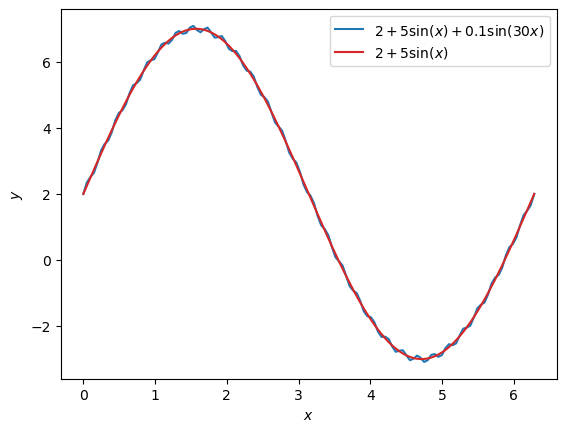

In [4]:
def f(x):
    """ 2 + 5sin(x) + 0.1sin(30x)"""
    return 2 + 5*np.sin(x) + 0.1*np.sin(30*x)

def g(x):
    """ 2 + 5sin(x) """
    return 2 + 5*np.sin(x)

xlist = np.linspace(0, 2*np.pi, 128)

fig, ax = plt.subplots()
ax.plot(xlist, f(xlist), c='tab:blue', label=r'$2 + 5\sin(x) + 0.1\sin(30x)$')
ax.plot(xlist, g(xlist), c='tab:red', label=r'$2 + 5\sin(x)$')
ax.set(xlabel=r'$x$', ylabel=r'$y$')
ax.legend()
plt.show()

(b) Create a plot that contains:
- (i) the analytically computed $f'(x)$,
- (ii) the analytically computed $g'(x)$, and
- (iii) the forward-diﬀerence approximation to $f'(x)$, using adjacent points on your grid.
- (iv) the forward-diﬀerence approximation to $f'(x)$, using grid points which are twice removed (e.g., to estimate the derivative at $x_{10}$ you use the function values at $x_{12}$ and $x_{10}$). Observe that this set of points exhibits "noise" with smaller amplitude; this is because we have employed a larger step size $h$ and have thereby smoothed out some of the
"unphysical" oscillations due to the third term. (Parts (b) and (c) are employing the forward-diﬀerence approximation, i.e., we were able to do a better job without turning to a better finite-diﬀerence approximation.)


In [5]:
xlist = np.linspace(0, 2*np.pi, 257)
ylist = f(xlist) 

# since evenly spaced points
h = xlist[1] - xlist[0]

ylistForwarded = np.roll(ylist, -1)
fd_approx = (ylistForwarded[:] - ylist[:])/h

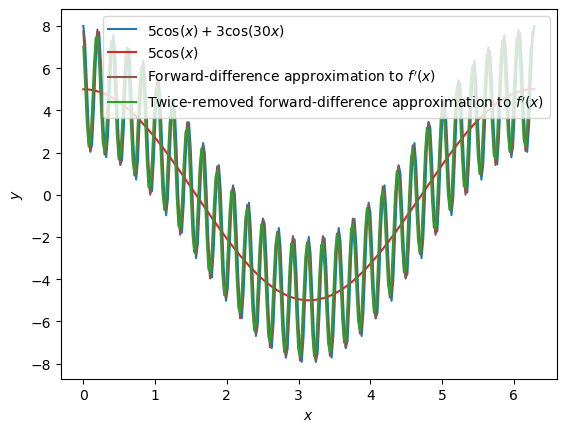

In [6]:
def fp(x):
    """ returns f'(x) = 5cos(x) + 3cos(30x) """
    return 5*np.cos(x) + 0.1*np.cos(30*x)*30

def gp(x):
    """ returns g'(x) = 5cos(x) """
    return 5*np.cos(x)

xlist = np.linspace(0, 2*np.pi, 257)
ylist = f(xlist) 

# since evenly spaced points
h = xlist[1] - xlist[0]

ylistForwarded = np.roll(ylist, -1)
fd_approx = (ylistForwarded[:-1] - ylist[:-1])/h

xlist = np.linspace(0, 2*np.pi, 257)
ylist = f(xlist) 

# twice-removed point
hTwice = xlist[2] - xlist[0]
fd_approxTwice = (ylist[2:] - ylist[:-2]) / hTwice

fig, ax = plt.subplots()
ax.plot(xlist, fp(xlist), c='tab:blue', label=r'$5\cos(x) + 3\cos(30x)$')
ax.plot(xlist, gp(xlist), c='tab:red', label=r'$5\cos(x)$')
ax.plot(xlist[:-1], fd_approx, c='tab:brown', label=r"Forward-difference approximation to $f'(x)$")
ax.plot(xlist[:-2], fd_approxTwice, c='tab:green', label=r"Twice-removed forward-difference approximation to $f'(x)$")
ax.set(xlabel=r'$x$', ylabel=r'$y$')
ax.legend()
plt.show()

(c) Create a plot that contains:
- (i) the analytically computed $f''(x)$,
- (ii) the central-diﬀerence approximation to the second derivative of $f(x)$ using the grid points $f(x_i)$.

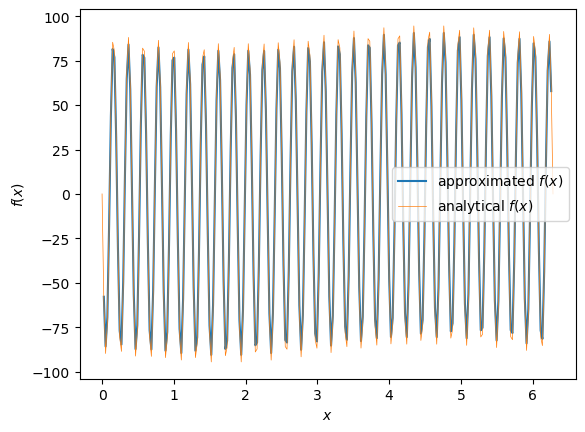

In [12]:
plt.plot(xlist[1:-1], (np.roll(ylist,-1) - 2*ylist + np.roll(ylist, 1))[1:-1]/(xlist[1]-xlist[0])**2, label=r'approximated $f''(x)$')
plt.plot(xlist, -5*np.sin(xlist) - 90*np.sin(xlist*30), lw=0.5, label=r'analytical $f''(x)$')
plt.legend()
plt.xlabel(r'$x$')
plt.ylabel(r'$f''(x)$')
plt.show()